In [22]:
import numpy as np
from scipy.spatial import distance_matrix
import pandas as pd

cities = [
    'New York', 'Los Angeles', 'Dallas', 'Boston', 'Nashville', 'Phoenix',
    'Las Vegas', 'Louisville', 'Miami', 'Atlanta', 'Tucson', 'Denver',
    'Chicago', 'Minneapolis', 'St. Louis', 'Houston', 'New Orleans',
    'Charlotte', 'Philadelphia', 'Detroit', 'San Antonio', 'Kansas City',
    'Salt Lake City', 'Washington DC', 'Portland'
]

lat_lon = [
    [40.7128, -74.0060],
    [34.0549, -118.2426],
    [32.7767, -96.7970],
    [42.3555, -71.0565],
    [36.1627, -86.7816],
    [33.4483, -112.0725],
    [36.1716, -115.1391],
    [38.2469, -85.7664],
    [25.7617, -80.1918],
    [33.7501, -84.3885],
    [32.2540, -110.9742],
    [39.7392, -104.9903],
    [41.8832, -87.6324],
    [44.9778, -93.2650],
    [38.6274, -90.1982],
    [29.7601, -95.3701],
    [29.9509, -90.0758],
    [35.2216, -80.8401],
    [39.9526, -75.1652],
    [42.3297, -83.0425],
    [29.4252, -98.4946],
    [39.0997, -94.5783],
    [40.7606, -111.8762],
    [38.9072, -77.0369],
    [45.5152, -122.6784],
]
df = pd.DataFrame(lat_lon, columns=('lat', 'lon'), index=cities)

flightdistance = pd.DataFrame(
    distance_matrix(df.values, df.values),
    index=df.index,
    columns=df.index
)

filename = 'datamatrix.csv'
flightdistance.to_csv(filename)


/Users/laurenhensley/323Project1/my_notebook_env/lib/python3.12/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Dimension of X after MDS = (25, 2)


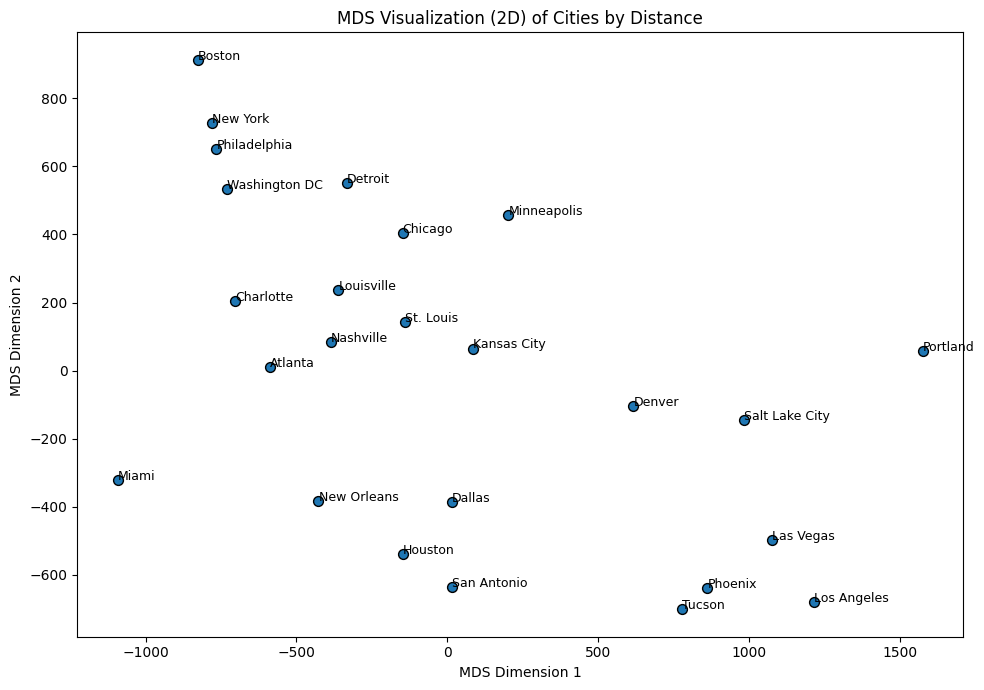

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
import pandas as pd

data = flightdistance.values  # or load from CSV as shown above

n_components = 2
mds = MDS(n_components=n_components, dissimilarity='precomputed', random_state=0)

#Fit the MDS model to the distance matrix
X_reduced = mds.fit_transform(data)
print('Dimension of X after MDS =', X_reduced.shape)

#Example plotting: scatter and annotate with city names (from dfdf.index)
plt.figure(figsize=(10, 7))
sc = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], s=50, edgecolor='k')
for i, name in enumerate(dfdf.index):
    plt.text(X_reduced[i, 0] + 0.02, X_reduced[i, 1] + 0.02, name, fontsize=9)

plt.title("MDS Visualization (2D) of Cities by Distance")
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")
plt.tight_layout()
plt.show()